# Search: Solving a Maze Using a Goal-based Agent

Student Name: 

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for pathfinding in mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

The agent must use a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. This is a planing exercise for a goal-based agent, so you do not need to implement an environment, just use the map to search for a path. Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the path and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. We do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. Here is the small example maze:

In [78]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [79]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

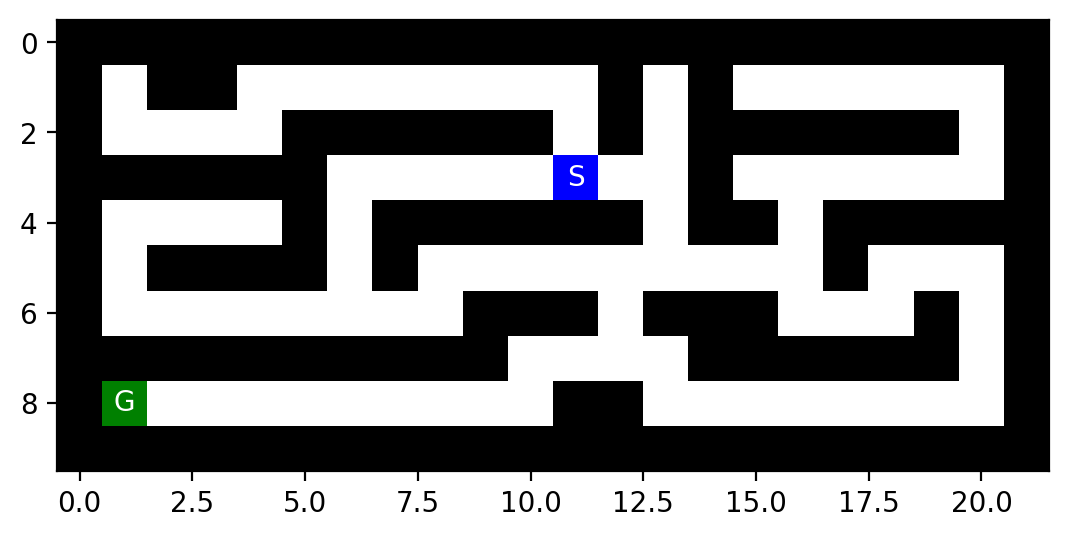

In [80]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [81]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (3, 11)
Goal location: (8, 1)


Helper function documentation.

In [82]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage: 
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        Build an animation from a list of mazes. Assumes that results has the elements:
        path, reached, actions and maze_anim with a list of maze arrays.
    
    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one. 
        Caution: there is no error checking!
        
        Parameters:
        maze: a array with characters prodced by parse_maze()
        what: the letter to be found ('S' for start and 'G' for goal)
        
        Returns:
        a tupple (x, y) for the found position.
    
    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).
    
    maze_to_matrix(maze)
        convert a maze a numeric numpy array for visualization via imshow.
    
 

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## Tree structure

Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [83]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [wall maze](wall_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty 2_maze](empty_2_maze.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can swich the next block from code to Markdown and use formating.

In [84]:
# Your answer goes here
# Initial State:
#     - Vị trí xuất phát của agent trong mê cung, ký hiệu là s0.
#     - Biểu diễn bằng tọa độ (x0, y0).
# Actions:
#     - Các hành động có thể thực hiện: {Up, Down, Left, Right}.
#     - Chỉ hợp lệ nếu ô tiếp theo không phải là tường.
# Transition Model:
#     - Xác định trạng thái kế tiếp sau khi thực hiện một hành động.
#     - Nếu agent ở (x, y) và thực hiện hành động a, thì:
#         T(s, a) = (x’, y’) 
#     - Với điều kiện (x’, y’) không vượt biên và không rơi vào tường.
# Goal State:
#     - Trạng thái cần đạt: sg = (xg, yg).
#     - Điều kiện dừng: tìm được đường đi từ s0 đến sg.
# Path Cost:
#     - Mỗi bước đi có chi phí 1.
#     - Tổng chi phí = số bước đi trong đường đi.
#       C(p) = n, với n là số bước.
# Problem Size:
#     - Số trạng thái hợp lệ = số ô trống trong mê cung.
#     - Nếu mê cung có kích thước m × n, thì số trạng thái tối đa:
#         |S| ≤ m × n

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

In [85]:
# Your answer goes here
# Ước lượng kích thước bài toán (problem size) trong mê cung

# Giả sử mê cung là một lưới m_rows × m_cols, trong đó mỗi ô hoặc là trống (có thể đi) hoặc là tường.
# Gọi tập các ô trống là X.

# 1) n : kích thước không gian trạng thái (state space size)
#    - Định nghĩa: số trạng thái khác nhau mà agent có thể đứng.
#    - Với mê cung dạng lưới: n = |X|.
#    - Cách xác định: đếm tất cả các ô trống (không phải tường).
#    - Ví dụ: mê cung 10×10 có 30 ô tường → n = 100 - 30 = 70.

# 2) d : độ sâu của lời giải tối ưu (depth of optimal solution)
#    - Định nghĩa: số bước đi ngắn nhất từ trạng thái start (s0) tới goal (sg).
#    - Cách xác định:
#        - Dùng BFS (Breadth-First Search) vì mỗi bước có chi phí bằng nhau.
#        - BFS trả về số bước ngắn nhất, chính là d.
#    - Cách ước lượng:
#        - Cận dưới: khoảng cách Manhattan giữa start và goal:
#          d ≥ |x0 - xg| + |y0 - yg|
#        - Cận trên: d ≤ n - 1 (không thể đi nhiều hơn số ô trống còn lại).

# 3) m : độ sâu tối đa của cây tìm kiếm (maximum depth)
#    - Nếu dùng graph-search (có kiểm tra lặp lại trạng thái):
#        m = n - 1 (vì tối đa đi qua tất cả ô trống khác nhau).
#    - Nếu dùng tree-search (không kiểm tra lặp lại):
#        m về lý thuyết là vô hạn (có thể đi vòng lặp mãi). Thực tế thường đặt giới hạn độ sâu.

# 4) b : hệ số phân nhánh tối đa (maximum branching factor)
#    - Định nghĩa: số lượng trạng thái con tối đa có thể sinh ra từ một trạng thái.
#    - Trong mê cung 4 hướng (lên, xuống, trái, phải): b ≤ 4.
#    - Cách xác định:
#        - Với mỗi ô trống, đếm số nước đi hợp lệ (không vượt biên, không đụng tường).
#        - b_max = max_s (số nước đi hợp lệ tại s).
#        - b_avg = trung bình số nước đi hợp lệ trên toàn bộ các ô trống.
#    - Thông thường:
#        - Ô nằm trong lưới, không sát tường → 4 hướng
#        - Ô biên → 3 hướng
#        - Ô góc → 2 hướng
#        - Nếu xung quanh nhiều tường, có thể chỉ còn 1 hoặc 0 hướng.

# ---

# ### Quy trình thực tế để xác định n, d, m, b cho một mê cung cụ thể:
# 1. Duyệt toàn bộ mê cung, đếm số ô trống:
#    n = |X|

# 2. Với mỗi ô trống, đếm số nước đi hợp lệ:
#    - Lấy max để được b_max
#    - Lấy trung bình để được b_avg

# 3. Chạy BFS từ start đến goal:
#    - Nếu tìm được đường → d = độ dài đường ngắn nhất
#    - Nếu không tìm được đường → d = ∞ (vô nghiệm)

# 4. Đặt m:
#    - Graph-search: m = n - 1
#    - Tree-search: m = ∞ hoặc giá trị cắt (cutoff depth)

# ---

# Ví dụ (mê cung 10×10, start=(0,0), goal=(9,9)):
# - Có 30 ô tường → n = 70
# - Khoảng cách Manhattan: d ≥ |0-9| + |0-9| = 18
# - BFS thực tế tìm được d = 26
# - b_max = 4 (thường ở giữa lưới), b_avg có thể ≈ 2.8
# - m = n - 1 = 69 (nếu graph-search)

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [86]:
# Your code goes here
from collections import deque
import heapq

def get_neighbors(pos, grid):
    r, c = pos
    moves = [(-1,0,"U"), (1,0,"D"), (0,-1,"L"), (0,1,"R")]
    for dr, dc, action in moves:
        nr, nc = r+dr, c+dc
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]) and grid[nr][nc] != "X":
            yield (nr, nc), action

def reconstruct(node):
    path = []
    while node:
        path.append(node.pos)
        node = node.parent
    return path[::-1]

# BFS
def bfs(grid, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = deque([start_node])   # FIFO queue
    visited = {start}                # avoid revisiting

    # --- metrics ---
    nodes_expanded = 0
    max_tree_depth = 0
    max_nodes_in_memory = 1
    max_frontier_size = 1

    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1
        max_tree_depth = max(max_tree_depth, node.cost)

        if node.pos == goal:
            return {
                "path": reconstruct(node),
                "cost": node.cost,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_tree_depth,
                "max_nodes_in_memory": max_nodes_in_memory,
                "max_frontier_size": max_frontier_size
            }

        for (npos, action) in get_neighbors(node.pos, grid):
            if npos not in visited:
                visited.add(npos)
                child = Node(npos, node, action, node.cost + 1)
                frontier.append(child)

        # update memory stats
        max_frontier_size = max(max_frontier_size, len(frontier))
        max_nodes_in_memory = max(max_nodes_in_memory,
                                  len(frontier) + len(visited))

    return {"error": "no path"}


# def bfs(grid, start, goal):
#     # create the start node
#     start_node = Node(start, None, None, 0)
#     frontier = deque([start_node])   # FIFO queue
#     visited = {start}                # to avoid revisiting
#     while frontier:
#         node = frontier.popleft()
#         # check goal
#         if node.pos == goal:
#             return {"path": reconstruct(node), "cost": node.cost}
#         # expand neighbors
#         for (npos, action) in get_neighbors(node.pos, grid):
#             if npos not in visited:
#                 visited.add(npos)
#                 frontier.append(Node(npos, node, action, node.cost + 1))
#     return {"error": "no path"}


# DFS
def dfs(grid, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = [start_node]          # stack (LIFO)
    visited = {start}
    # --- metrics ---
    nodes_expanded = 0
    max_tree_depth = 0
    max_nodes_in_memory = 1
    max_frontier_size = 1
    while frontier:
        node = frontier.pop()
        nodes_expanded += 1
        max_tree_depth = max(max_tree_depth, node.cost)
        if node.pos == goal:
            return {
                "path": reconstruct(node),
                "cost": node.cost,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_tree_depth,
                "max_nodes_in_memory": max_nodes_in_memory,
                "max_frontier_size": max_frontier_size
            }
        for (npos, action) in get_neighbors(node.pos, grid):
            if npos not in visited:
                visited.add(npos)
                child = Node(npos, node, action, node.cost + 1)
                frontier.append(child)
        # update memory stats
        max_frontier_size = max(max_frontier_size, len(frontier))
        max_nodes_in_memory = max(max_nodes_in_memory,
                                  len(frontier) + len(visited))
    return {"error": "no path"}


# def dfs(grid, start, goal):
#     start_node = Node(start, None, None, 0)
#     frontier = [start_node]      # stack (LIFO)
#     visited = {start}            # avoid revisiting
#     while frontier:
#         node = frontier.pop()
#         # check goal
#         if node.pos == goal:
#             return {"path": reconstruct(node), "cost": node.cost}
#         # expand neighbors
#         for (npos, action) in get_neighbors(node.pos, grid):
#             if npos not in visited:
#                 visited.add(npos)
#                 frontier.append(Node(npos, node, action, node.cost + 1))
#     return {"error": "no path"}




How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

In [87]:
# Discussion
# Trong tìm kiếm cây, BFS chỉ hoàn tất nếu không gian tìm kiếm hữu hạn và phi chu trình. 
# Khi có chu trình, BFS liên tục khám phá lại các nút giống nhau và có thể mở rộng vô hạn các trạng thái trùng lặp.

# DFS thậm chí còn tệ hơn: trong đồ thị chu trình, nó có thể đi theo một chu trình mãi mãi và không bao giờ quay lại, do đó nó không hoàn tất.
# Để giải quyết vấn đề này, em nghĩ nên sử dụng tìm kiếm đồ thị, ghi lại các trạng thái đã khám phá trong một tập hợp đã thăm/đã đạt, ngăn ngừa vòng lặp và đảm bảo kết thúc.

Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

In [88]:
# Discussion

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

In [89]:
# Your code goes here
import heapq
import itertools
counter = itertools.count()

def gbfs(grid, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = [(h(start, goal), next(counter), start_node)]
    visited = {start}

    # --- metrics ---
    nodes_expanded = 0
    max_tree_depth = 0
    max_nodes_in_memory = 1
    max_frontier_size = 1

    while frontier:
        _, _, node = heapq.heappop(frontier)
        nodes_expanded += 1
        max_tree_depth = max(max_tree_depth, node.cost)

        if node.pos == goal:
            return {
                "path": reconstruct(node),
                "cost": node.cost,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_tree_depth,
                "max_nodes_in_memory": max_nodes_in_memory,
                "max_frontier_size": max_frontier_size
            }

        for (npos, action) in get_neighbors(node.pos, grid):
            if npos not in visited:
                visited.add(npos)
                child = Node(npos, node, action, node.cost + 1)
                heapq.heappush(frontier, (h(npos, goal), next(counter), child))

        max_frontier_size = max(max_frontier_size, len(frontier))
        max_nodes_in_memory = max(max_nodes_in_memory, len(frontier) + len(visited))

    return {"error": "no path"}

def astar(grid, start, goal):
    start_node = Node(start, None, None, 0)
    frontier = [(h(start, goal), next(counter), start_node)]
    g = {start: 0}

    # --- metrics ---
    nodes_expanded = 0
    max_tree_depth = 0
    max_nodes_in_memory = 1
    max_frontier_size = 1

    while frontier:
        _, _, node = heapq.heappop(frontier)
        nodes_expanded += 1
        max_tree_depth = max(max_tree_depth, node.cost)

        if node.pos == goal:
            return {
                "path": reconstruct(node),
                "cost": node.cost,
                "nodes_expanded": nodes_expanded,
                "max_tree_depth": max_tree_depth,
                "max_nodes_in_memory": max_nodes_in_memory,
                "max_frontier_size": max_frontier_size
            }

        for (npos, action) in get_neighbors(node.pos, grid):
            newg = node.cost + 1
            if npos not in g or newg < g[npos]:
                g[npos] = newg
                f = newg + h(npos, goal)
                child = Node(npos, node, action, newg)
                heapq.heappush(frontier, (f, next(counter), child))

        max_frontier_size = max(max_frontier_size, len(frontier))
        max_nodes_in_memory = max(max_nodes_in_memory, len(frontier) + len(g))

    return {"error": "no path"}




Are your implementations complete and optimal? What is the time and space complexity?

In [90]:
# Discussion

## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [91]:
# Add code
def parse_maze_simple(maze_str):
    grid = []
    start = None
    goal = None
    lines = maze_str.strip().split("\n")
    for r, line in enumerate(lines):
        row = list(line)
        grid.append(row)
        for c, val in enumerate(row):
            if val == "S":
                start = (r, c)
            elif val == "G":
                goal = (r, c)

    if start is None or goal is None:
        raise ValueError("Maze must contain S (start) and G (goal).")

    return grid, start, goal

from tabulate import tabulate  # install via pip if needed

def run_all(maze_str, name="maze"):
    grid, start, goal = parse_maze_simple(maze_str)
    if not isinstance(start, tuple):
        start = tuple(start)
    if not isinstance(goal, tuple):
        goal = tuple(goal)

    print(f"Running on {name} - size {len(grid)}x{len(grid[0])}; start={start}, goal={goal}")
    results = {}

    rows = []  # for table

    for alg, func in [("BFS", bfs),
                      ("DFS", dfs),
                      ("GBFS", gbfs),
                      ("A*", astar)]:
        try:
            res = func(grid, start, goal)
        except Exception as e:
            res = {"error": str(e)}

        results[alg] = res

        if "error" in res:
            rows.append([alg, "X", "X", "X", "X", "X"])
            print(f"{alg}: error → {res['error']}")
        else:
            rows.append([
                alg,
                res.get("cost", "-"),
                res.get("nodes_expanded", "-"),
                res.get("max_tree_depth", "-"),
                res.get("max_nodes_in_memory", "-"),
                res.get("max_frontier_size", "-")
            ])
            print(f"{alg}: cost={res['cost']}, path_length={len(res['path'])}")

    # Pretty print table
    print("\nComparison Table:")
    print(tabulate(rows, headers=["algorithm", "path cost", "# nodes expanded",
                                  "max tree depth", "max nodes in memory", "max frontier size"],
                   tablefmt="github"))

    return results


with open("small_maze.txt") as f:
    maze_str = f.read()

res_small = run_all(maze_str, "small_maze.txt")


Running on small_maze.txt - size 10x22; start=(3, 11), goal=(8, 1)
BFS: cost=19, path_length=20
DFS: cost=37, path_length=38
GBFS: cost=29, path_length=30
A*: cost=19, path_length=20

Comparison Table:
| algorithm   |   path cost |   # nodes expanded |   max tree depth |   max nodes in memory |   max frontier size |
|-------------|-------------|--------------------|------------------|-----------------------|---------------------|
| BFS         |          19 |                 92 |               19 |                    95 |                   8 |
| DFS         |          37 |                 38 |               37 |                    51 |                   7 |
| GBFS        |          29 |                 40 |               29 |                    49 |                   5 |
| A*          |          19 |                 54 |               19 |                    66 |                   8 |


Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

Running on small_maze.txt - size 10x22; start=(3, 11), goal=(8, 1)
BFS: cost=19, path_length=20
DFS: cost=37, path_length=38
GBFS: cost=29, path_length=30
A*: cost=19, path_length=20

Comparison Table:
| algorithm   |   path cost |   # nodes expanded |   max tree depth |   max nodes in memory |   max frontier size |
|-------------|-------------|--------------------|------------------|-----------------------|---------------------|
| BFS         |          19 |                 92 |               19 |                    95 |                   8 |
| DFS         |          37 |                 38 |               37 |                    51 |                   7 |
| GBFS        |          29 |                 40 |               29 |                    49 |                   5 |
| A*          |          19 |                 54 |               19 |                    66 |                   8 |


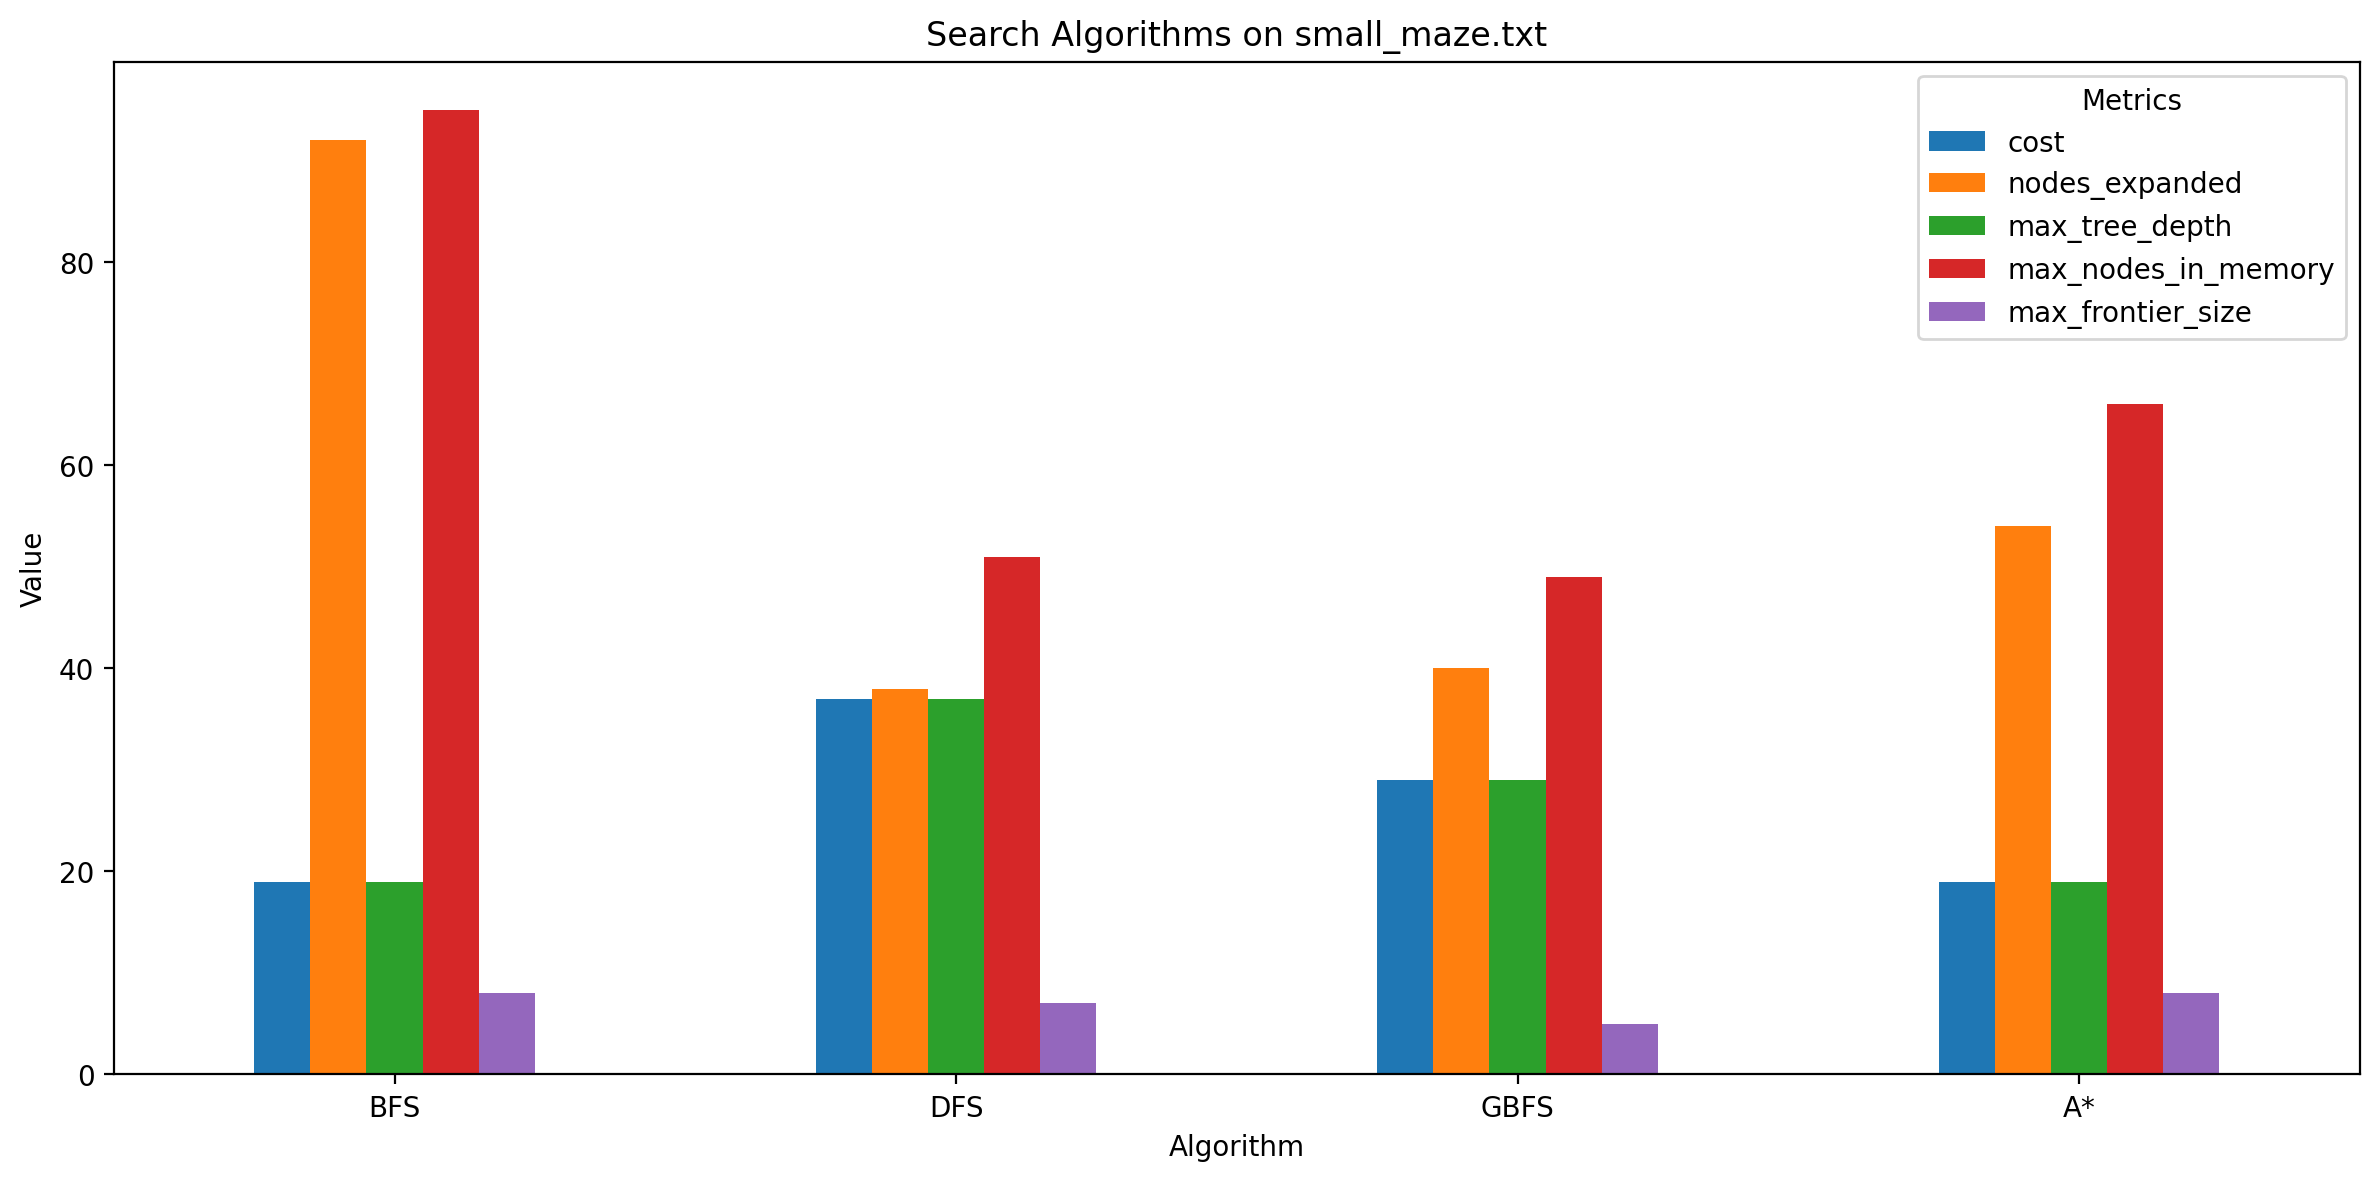

      cost  nodes_expanded  max_tree_depth  max_nodes_in_memory  \
BFS     19              92              19                   95   
DFS     37              38              37                   51   
GBFS    29              40              29                   49   
A*      19              54              19                   66   

      max_frontier_size  
BFS                   8  
DFS                   7  
GBFS                  5  
A*                    8  


In [102]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_results(results, title="Search Algorithms Comparison"):
    # Convert results dict → DataFrame
    df = pd.DataFrame(results).T  # alg names as rows
    
    # Drop "path" if present (too long, not numeric)
    if "path" in df.columns:
        df = df.drop(columns=["path"])
    
    # Ensure all columns are numeric
    df = df.apply(pd.to_numeric, errors="ignore")
    
    # Plot grouped bar chart
    ax = df.plot(kind="bar", figsize=(12, 6))
    plt.title(title)
    plt.ylabel("Value")
    plt.xlabel("Algorithm")
    plt.xticks(rotation=0)
    plt.legend(title="Metrics")
    plt.tight_layout()
    plt.show()
    
    return df

# Example usage:
with open("small_maze.txt") as f:
    maze_str = f.read()

results = run_all(maze_str, "small_maze.txt")
df = plot_results(results, title="Search Algorithms on small_maze.txt")

print(df)  # optional: print numeric table


Discuss the most important lessons you have learned from implementing the different search strategies. 

In [93]:
# Add discussion

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [ ]:
# Your code/answer goes here
# IDS
# Depth-limited Search (helper for IDS)
def dls(node, goal, limit, grid, visited=None):
    if visited is None:
        visited = set()
    if node.pos == goal:
        return node
    if limit == 0:
        return None
    visited.add(node.pos)
    for (npos, action) in get_neighbors(node.pos, grid):
        if npos not in visited:
            child = Node(npos, node, action, node.cost+1)
            res = dls(child, goal, limit-1, grid, visited)
            if res:
                return res
    return None

# Iterative Deepening Search
def ids(grid, start, goal):
    depth = 0
    while True:
        res = dls(Node(start, None, None, 0), goal, depth, grid)
        if res:
            return {"path": reconstruct(res), "cost": res.cost}
        depth += 1
        if depth > len(grid) * len(grid[0]):  # safeguard
            return {"error": "no path"}


### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

In [ ]:
# Your code/answer goes here
def run_all_add_ids(maze_str, name="maze"):
    grid, start, goal = parse_maze_simple(maze_str)
    if not isinstance(start, tuple):
        start = tuple(start)
    if not isinstance(goal, tuple):
        goal = tuple(goal)

    print(f"Running on {name} - size {len(grid)}x{len(grid[0])}; start={start}, goal={goal}")
    results = {}
    for alg, func in [
        ("BFS", bfs), 
        ("DFS", dfs), 
        ("GBFS", gbfs), 
        ("A*", astar), 
        ("IDS", ids)  
    ]:
        try:
            res = func(grid, start, goal)
        except Exception as e:
            res = {"error": str(e)}
        results[alg] = res
        if res and "path" in res and res["path"]:
            print(f"{alg}: cost={res['cost']}, path_length={len(res['path'])}")
        else:
            print(f"{alg}: no path or error: {res}")
    return results

with open("medium_maze.txt") as f:
    medium_maze_str = f.read()

results = run_all_add_ids(medium_maze_str, "medium_maze.txt")

Running on medium_maze.txt - size 18x36; start=(1, 34), goal=(16, 1)
BFS: cost=68, path_length=69
DFS: cost=130, path_length=131
GBFS: cost=74, path_length=75
A*: cost=68, path_length=69


## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [96]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [97]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [98]:
# Your code/answer goes here